In [1]:
import pandas as pd

df_judge1 = pd.read_csv('../Human evaluations/Judge 1.csv', on_bad_lines='skip', sep=';')
df_judge2 = pd.read_csv('../Human evaluations/Judge 2.csv', on_bad_lines='skip', sep=';')
df_judge3 = pd.read_csv('../Human evaluations/Judge 3.csv', on_bad_lines='skip', sep=';')

In [2]:
import pandas as pd

datasets = [
    ('Stress', '../Datasets/Human Stress Prediction.csv', 'label'),
    ('Fetal Health', '../Datasets/Fetal Health Classification.csv', 'fetal_health'),
    ('Diabetes', '../Datasets/Diabetes Health Indicators Dataset.csv', 'Diabetes_012'),
    ('Lung Cancer', '../Datasets/Lung Cancer Dataset.csv', 'LUNG_CANCER'),
    ('Suicide Detection', '../Datasets/Suicide and Depression Detection.csv', 'class'),
]

for name, path, label in datasets:
    df = pd.read_csv(path)
    n_instances = df.shape[0]
    n_columns = df.shape[1]
    n_classes = df[label].nunique() if label in df.columns else 'Label not found'

    print(f"📊 {name}")
    print(f"  Instances: {n_instances}")
    print(f"  Columns: {n_columns}")
    print(f"  Classes in '{label}': {n_classes}\n")

📊 Stress
  Instances: 2838
  Columns: 7
  Classes in 'label': 2

📊 Fetal Health
  Instances: 2126
  Columns: 22
  Classes in 'fetal_health': 3

📊 Diabetes
  Instances: 253680
  Columns: 22
  Classes in 'Diabetes_012': 3

📊 Lung Cancer
  Instances: 3000
  Columns: 16
  Classes in 'LUNG_CANCER': 2

📊 Suicide Detection
  Instances: 232074
  Columns: 3
  Classes in 'class': 2



### Kendall's tau

In [3]:
from scipy.stats import kendalltau
import pandas as pd
import numpy as np

def bootstrap_kendalltau(x, y, n_boot=1000, seed=42):
    np.random.seed(seed)
    n = len(x)
    taus = []

    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        tau, _ = kendalltau(x[idx], y[idx])
        taus.append(tau)

    return np.percentile(taus, [2.5, 97.5])

characteristics = ['Relatedness', 'Error', 'Clarity', 'Coverage']

for caract in characteristics:
    print(f"\n🔎 Kendall's Tau for: {caract}")

    df_kendall = pd.DataFrame({
        'Judge 1': df_judge1[caract].values,
        'Judge 2': df_judge2[caract].values,
        'Judge 3': df_judge3[caract].values
    })

    pares = [('Judge 1', 'Judge 2'), ('Judge 1', 'Judge 3'), ('Judge 2', 'Judge 3')]

    for a, b in pares:
        tau, p = kendalltau(df_kendall[a], df_kendall[b])
        ci_lower, ci_upper = bootstrap_kendalltau(df_kendall[a].values, df_kendall[b].values)
        print(f"{a} vs {b}: τ = {tau:.3f}, p = {p:.4f}, CI95% = [{ci_lower:.3f}, {ci_upper:.3f}]")



🔎 Kendall's Tau for: Relatedness
Judge 1 vs Judge 2: τ = 0.604, p = 0.0000, CI95% = [0.461, 0.731]
Judge 1 vs Judge 3: τ = 0.547, p = 0.0000, CI95% = [0.380, 0.694]
Judge 2 vs Judge 3: τ = 0.531, p = 0.0000, CI95% = [0.352, 0.687]

🔎 Kendall's Tau for: Error
Judge 1 vs Judge 2: τ = 0.573, p = 0.0000, CI95% = [0.398, 0.720]
Judge 1 vs Judge 3: τ = 0.550, p = 0.0000, CI95% = [0.392, 0.692]
Judge 2 vs Judge 3: τ = 0.593, p = 0.0000, CI95% = [0.451, 0.716]

🔎 Kendall's Tau for: Clarity
Judge 1 vs Judge 2: τ = 0.507, p = 0.0000, CI95% = [0.351, 0.645]
Judge 1 vs Judge 3: τ = 0.657, p = 0.0000, CI95% = [0.543, 0.750]
Judge 2 vs Judge 3: τ = 0.540, p = 0.0000, CI95% = [0.392, 0.656]

🔎 Kendall's Tau for: Coverage
Judge 1 vs Judge 2: τ = 0.569, p = 0.0000, CI95% = [0.422, 0.690]
Judge 1 vs Judge 3: τ = 0.593, p = 0.0000, CI95% = [0.427, 0.730]
Judge 2 vs Judge 3: τ = 0.390, p = 0.0001, CI95% = [0.187, 0.582]


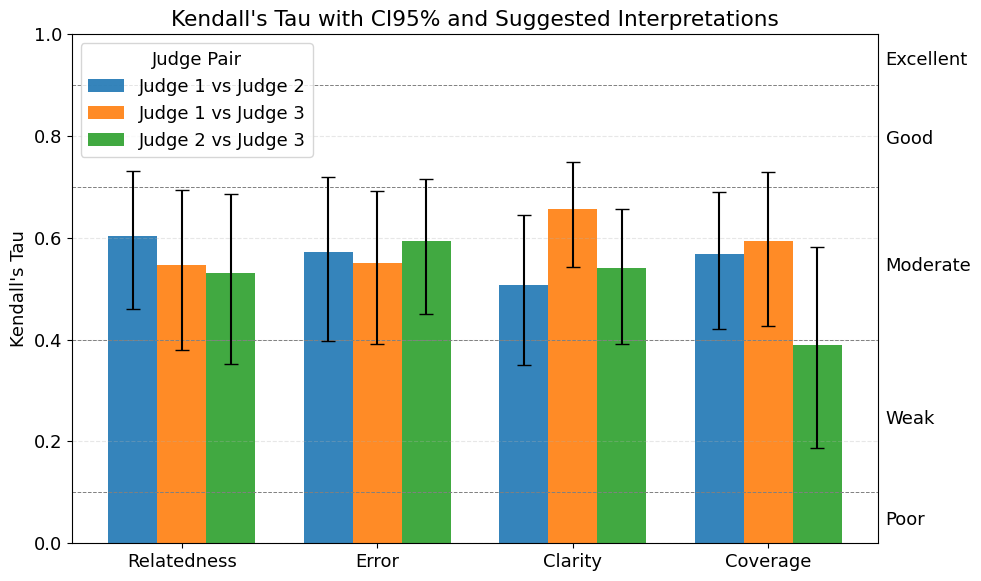

In [4]:
import matplotlib.pyplot as plt

pairs = ['Judge 1 vs Judge 2', 'Judge 1 vs Judge 3', 'Judge 2 vs Judge 3']
characteristics = ['Relatedness', 'Error', 'Clarity', 'Coverage']

values = {
    'Relatedness': [(0.604, 0.461, 0.731), (0.547, 0.380, 0.694), (0.531, 0.352, 0.687)],
    'Error':        [(0.573, 0.398, 0.720), (0.550, 0.392, 0.692), (0.593, 0.451, 0.716)],
    'Clarity':     [(0.507, 0.351, 0.645), (0.657, 0.543, 0.750), (0.540, 0.392, 0.656)],
    'Coverage':   [(0.569, 0.422, 0.690), (0.593, 0.427, 0.730), (0.390, 0.187, 0.582)],
}

# Configurations
n_caract = len(characteristics)
x = np.arange(n_caract)
bar_width = 0.25
offsets = [-bar_width, 0, bar_width]
colors = ['#1f77b4', '#ff7f0e', "#2ca02c"]

# Agreement levels
levels = {
    'Poor': (0.00, 0.09),
    'Weak': (0.10, 0.39),
    'Moderate': (0.40, 0.69),
    'Good': (0.70, 0.89),
    'Excellent': (0.90, 1.00),
}

# Plot
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=(10, 6))

for level, (start, end) in levels.items():
    y = start
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.7)
    ax.text(len(characteristics) - 0.4, (y+end)/2, level, va='center', ha='left', color='black')

for i, (pair, color) in enumerate(zip(pairs, colors)):
    means = [values[c][i][0] for c in characteristics]
    lowers = [values[c][i][1] for c in characteristics]
    uppers = [values[c][i][2] for c in characteristics]
    errors = [[m - l for m, l in zip(means, lowers)],
              [u - m for u, m in zip(uppers, means)]]

    ax.bar(x + offsets[i], means, width=bar_width, label=pair,
           yerr=errors, capsize=5, color=color, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(characteristics)
ax.set_ylabel("Kendall's Tau")
ax.set_title("Kendall's Tau with CI95% and Suggested Interpretations")
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Judge Pair', loc='upper left')

plt.tight_layout()
plt.show()


### Spearman

In [5]:
from scipy.stats import spearmanr

def bootstrap_spearmanr(x, y, n_boot=1000, seed=42):
    np.random.seed(seed)
    n = len(x)
    taus = []

    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        tau, _ = spearmanr(x[idx], y[idx])
        taus.append(tau)

    return np.percentile(taus, [2.5, 97.5])

for caract in characteristics:
    print(f"\n🔎 Spearman R for: {caract}")

    df_spearman = pd.DataFrame({
        'Judge 1': df_judge1[caract].values,
        'Judge 2': df_judge2[caract].values,
        'Judge 3': df_judge3[caract].values
    })

    pares = [('Judge 1', 'Judge 2'), ('Judge 1', 'Judge 3'), ('Judge 2', 'Judge 3')]

    for a, b in pares:
        correlation, p_value = spearmanr(df_spearman[a], df_spearman[b])
        ci_lower, ci_upper = bootstrap_spearmanr(df_spearman[a].values, df_spearman[b].values)
        print(f"{a} vs {b}: rho = {correlation:.3f}, p = {p_value:.4f}, CI95% = [{ci_lower:.3f}, {ci_upper:.3f}]")



🔎 Spearman R for: Relatedness
Judge 1 vs Judge 2: rho = 0.688, p = 0.0000, CI95% = [0.535, 0.817]
Judge 1 vs Judge 3: rho = 0.625, p = 0.0000, CI95% = [0.442, 0.772]
Judge 2 vs Judge 3: rho = 0.591, p = 0.0000, CI95% = [0.399, 0.758]

🔎 Spearman R for: Error
Judge 1 vs Judge 2: rho = 0.622, p = 0.0000, CI95% = [0.429, 0.779]
Judge 1 vs Judge 3: rho = 0.612, p = 0.0000, CI95% = [0.434, 0.759]
Judge 2 vs Judge 3: rho = 0.650, p = 0.0000, CI95% = [0.490, 0.783]

🔎 Spearman R for: Clarity
Judge 1 vs Judge 2: rho = 0.583, p = 0.0000, CI95% = [0.407, 0.732]
Judge 1 vs Judge 3: rho = 0.759, p = 0.0000, CI95% = [0.638, 0.844]
Judge 2 vs Judge 3: rho = 0.639, p = 0.0000, CI95% = [0.476, 0.758]

🔎 Spearman R for: Coverage
Judge 1 vs Judge 2: rho = 0.655, p = 0.0000, CI95% = [0.494, 0.777]
Judge 1 vs Judge 3: rho = 0.686, p = 0.0000, CI95% = [0.507, 0.818]
Judge 2 vs Judge 3: rho = 0.444, p = 0.0001, CI95% = [0.220, 0.651]


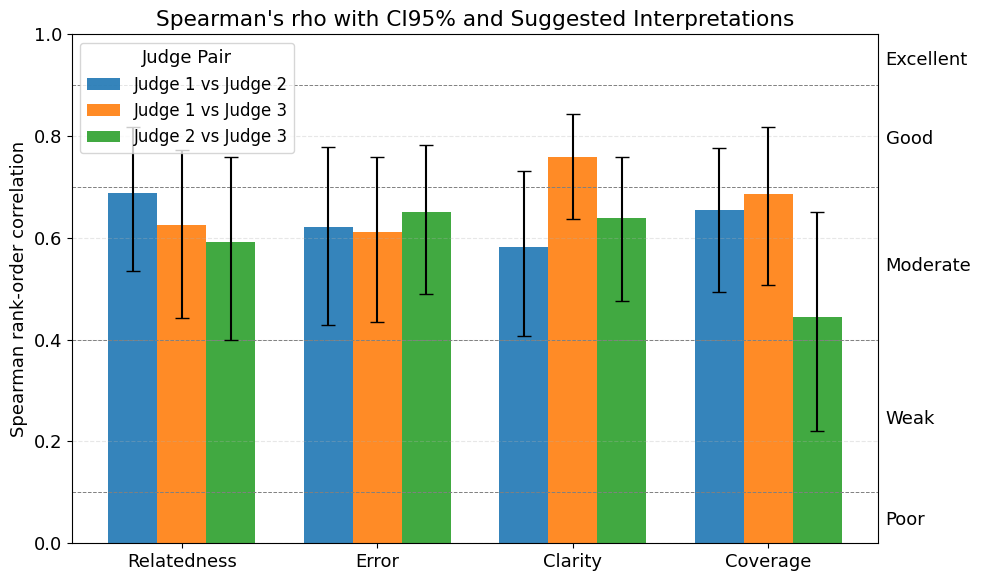

In [6]:
values = {
    'Relatedness': [(0.688, 0.535, 0.817), (0.625, 0.442, 0.772), (0.591, 0.399, 0.758)],
    'Error': [(0.622, 0.429, 0.779),(0.612, 0.434, 0.759),(0.650, 0.490, 0.783)],
    'Clarity': [(0.583, 0.407, 0.732),(0.759, 0.638, 0.844),(0.639, 0.476, 0.758)],
    'Coverage': [(0.655, 0.494, 0.777),(0.686, 0.507, 0.818),(0.444, 0.220, 0.651)]
}

# Plot
plt.rcParams.update({'font.size': 13})
fig, ax = plt.subplots(figsize=(10, 6))

for level, (start, end) in levels.items():
    y = start
    ax.axhline(y=y, color='gray', linestyle='--', linewidth=0.7)
    ax.text(len(characteristics) - 0.4, (y+end)/2, level, va='center', ha='left', color='black')

for i, (pair, color) in enumerate(zip(pairs, colors)):
    means = [values[c][i][0] for c in characteristics]
    lowers = [values[c][i][1] for c in characteristics]
    uppers = [values[c][i][2] for c in characteristics]
    errors = [[m - l for m, l in zip(means, lowers)],
              [u - m for u, m in zip(uppers, means)]]

    ax.bar(x + offsets[i], means, width=bar_width, label=pair,
           yerr=errors, capsize=5, color=color, alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(characteristics)
ax.set_ylabel("Spearman rank-order correlation")
ax.set_title("Spearman's rho with CI95% and Suggested Interpretations")
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Judge Pair', loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()


### Kendall's W

In [7]:
import kendall_w as kw

def bootstrap_kendall_w(data, n_bootstraps=1000, seed=42):
    np.random.seed(seed)
    w_values = []

    n = data.shape[0]
    for _ in range(n_bootstraps):
        idx = np.random.choice(n, n, replace=True)
        sampled = data.iloc[idx]

        ranks = np.argsort(np.argsort(sampled.values, axis=0), axis=0) + 1
        W = kw.compute_w(ranks.tolist())
        w_values.append(W)

    return np.percentile(w_values, [2.5, 97.5])  # CI95%

for caract in characteristics:
    matriz = pd.DataFrame({
        'Judge 1': df_judge1[caract].values,
        'Judge 2': df_judge2[caract].values,
        'Judge 3': df_judge3[caract].values
    })

    ci_lower, ci_upper = bootstrap_kendall_w(matriz)

    annotations = np.array(matriz)
    annotations = np.argsort(np.argsort(annotations, axis=0), axis=0) + 1
    annotations = annotations.tolist()

    W = kw.compute_w(annotations)
    print(f"{caract}: Kendall's W = {W:.3f} / Kendall's W CI95% = [{ci_lower:.2f}, {ci_upper:.2f}]")


Relatedness: Kendall's W = 0.723 / Kendall's W CI95% = [0.65, 0.83]
Error: Kendall's W = 0.701 / Kendall's W CI95% = [0.62, 0.81]
Clarity: Kendall's W = 0.790 / Kendall's W CI95% = [0.67, 0.82]
Coverage: Kendall's W = 0.698 / Kendall's W CI95% = [0.62, 0.81]


### ICC

In [8]:
import pingouin as pg

for caract in characteristics:
    df_icc = pd.DataFrame({
        'id': range(len(df_judge1)),
        'Judge 1': df_judge1[caract].values,
        'Judge 2': df_judge2[caract].values,
        'Judge 3': df_judge3[caract].values
    })

    df_long = df_icc.melt(id_vars='id', var_name='rater', value_name='value')
    icc_result = pg.intraclass_corr(data=df_long, targets='id', raters='rater', ratings='value')

    icc = icc_result.query("Type == 'ICC3k'")[['ICC', 'CI95%']].iloc[0]
    print(f"{caract}: ICC = {icc['ICC']:.3f}, CI95% = {icc['CI95%']}")


Relatedness: ICC = 0.813, CI95% = [0.73 0.88]
Error: ICC = 0.859, CI95% = [0.79 0.91]
Clarity: ICC = 0.834, CI95% = [0.76 0.89]
Coverage: ICC = 0.787, CI95% = [0.69 0.86]


## Statistical analysis

In [9]:
df1_unique = df_judge1.groupby(['Tool ID', 'Prompt'], as_index=False)[['Relatedness', 'Error', 'Clarity', 'Coverage']].mean()
df2_unique = df_judge2.groupby(['Tool ID', 'Prompt'], as_index=False)[['Relatedness', 'Error', 'Clarity', 'Coverage']].mean()
df3_unique = df_judge3.groupby(['Tool ID', 'Prompt'], as_index=False)[['Relatedness', 'Error', 'Clarity', 'Coverage']].mean()

merged = pd.merge(df1_unique, df2_unique, on=['Tool ID', 'Prompt'], suffixes=('_r1', '_r2'))
merged = pd.merge(merged, df3_unique, on=['Tool ID', 'Prompt'])

merged = merged.rename(columns={
    'Relatedness': 'Relatedness_r3',
    'Error': 'Error_r3',
    'Clarity': 'Clarity_r3',
    'Coverage': 'Coverage_r3'
})

cols = ['Relatedness', 'Error', 'Clarity', 'Coverage']

# Calculates the mean between two judges
for col in cols:
    merged[f'{col}_mean'] = merged[[f'{col}_r1', f'{col}_r2', f'{col}_r3']].mean(axis=1)

df_results = merged[['Tool ID', 'Prompt'] + [f'{col}_mean' for col in cols]]

df_results[[f'{col}_mean' for col in cols]] = df_results[[f'{col}_mean' for col in cols]].round(1)

prompts_sort = [
    "What are the main characteristics of the dataset?",
    "Are there any missing values? If so, in which columns and how many?",
    "Can you identify any outliers in the data?",
    "Generate relevant visualizations that help me understand the distribution of the data",
    "Make a complete EDA of my dataset"
]

df_results['Prompt'] = pd.Categorical(df_results['Prompt'], categories=prompts_sort, ordered=True)
df_results = df_results.sort_values(by='Prompt').reset_index(drop=True)

display(df_results)

C:\Users\fzagatti\AppData\Local\Temp\ipykernel_27668\3496585735.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_results[[f'{col}_mean' for col in cols]] = df_results[[f'{col}_mean' for col in cols]].round(1)
C:\Users\fzagatti\AppData\Local\Temp\ipykernel_27668\3496585735.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_results['Prompt'] = pd.Categorical(df_results['Prompt'], categories=prompts_sort, ordered=True)


,Tool ID,Prompt,Relatedness_mean,Error_mean,Clarity_mean,Coverage_mean
0,1,What are the main characteristics of the dataset?,2.7,3.9,2.1,2.3
1,2,What are the main characteristics of the dataset?,4.9,5.0,4.5,4.8
2,3,What are the main characteristics of the dataset?,2.8,2.1,2.5,2.5
3,1,"Are there any missing values? If so, in which ...",1.5,1.3,1.6,1.5
4,2,"Are there any missing values? If so, in which ...",5.0,5.0,5.0,5.0
5,3,"Are there any missing values? If so, in which ...",4.3,3.9,3.9,2.9
6,1,Can you identify any outliers in the data?,3.3,3.7,2.1,2.3
7,2,Can you identify any outliers in the data?,4.5,4.1,4.1,4.5
8,3,Can you identify any outliers in the data?,3.9,2.7,2.9,2.7
9,1,Generate relevant visualizations that help me ...,2.7,4.0,2.1,2.5


In [10]:
df_final = df_results.groupby('Tool ID')[['Relatedness_mean', 'Error_mean', 'Clarity_mean', 'Coverage_mean']].mean().reset_index()
display(df_final)

,Tool ID,Relatedness_mean,Error_mean,Clarity_mean,Coverage_mean
0,1,2.54,3.32,2.00,2.14
1,2,4.68,4.58,4.38,4.64
2,3,3.68,3.28,2.94,2.78


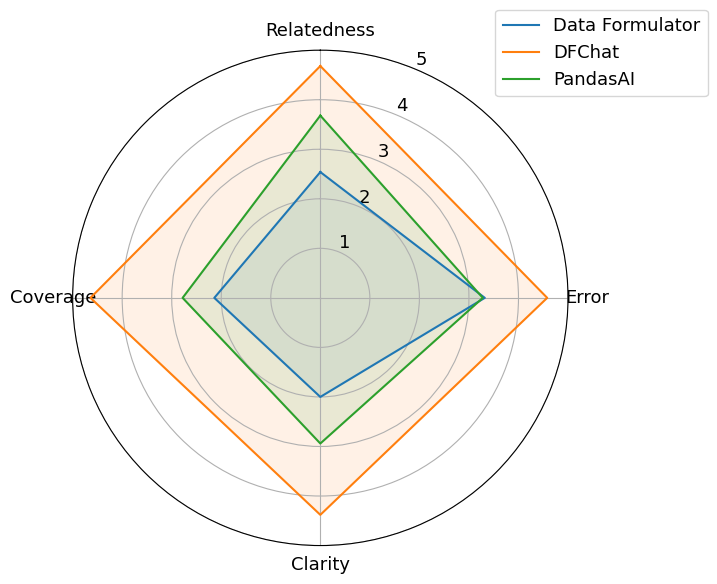

In [11]:
import numpy as np
import pandas as pd

data = {
    "Tool": ["Data Formulator", "DFChat", "PandasAI"],
    "Relatedness": [2.54, 4.68, 3.68],
    "Error": [3.32, 4.58, 3.28],
    "Clarity": [2.00, 4.38, 2.94],
    "Coverage": [2.14, 4.64, 2.78]
}

df = pd.DataFrame(data)

def plot_radar():
    df_radar = df.copy()
    categories = ['Relatedness', 'Error', 'Clarity', 'Coverage']
    labels = df_radar['Tool'].tolist()
    values = [df_radar.iloc[i][categories].tolist() for i in range(len(df_radar))]

    # Setup radar chart
    N = len(categories)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    values = [v + [v[0]] for v in values] 
    angles += [angles[0]]

    fig, ax = plt.subplots(figsize=(7, 6), subplot_kw=dict(polar=True)) 
    for i, val in enumerate(values):
        ax.plot(angles, val, label=labels[i])
        ax.fill(angles, val, alpha=0.1)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    ax.set_ylim(0, 5)
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

plot_radar()
